In [65]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
orders_qu=pd.read_csv("orders_qu.csv")
orderlines_qu=pd.read_csv("orderlines_qu.csv")
products_cl=pd.read_csv("products_cl.csv")

So we've loaded the files, and need to look at the discounts. This can be done by comparing the prices in orderlines with the prices in products. To simplify analysis, we might just as well merge everything together.

discount should be products_cl["price"]-orderlines_cl["price"]

In [67]:
products_cl.info()

<class 'pandas.DataFrame'>
RangeIndex: 9992 entries, 0 to 9991
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   str    
 1   name      9992 non-null   str    
 2   desc      9992 non-null   str    
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9946 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 468.5 KB


In [68]:
orderlines_qu.info()

<class 'pandas.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                53231 non-null  int64  
 1   id_order          53231 non-null  int64  
 2   product_id        53231 non-null  int64  
 3   product_quantity  53231 non-null  int64  
 4   sku               53231 non-null  str    
 5   unit_price        53231 non-null  float64
 6   date              53231 non-null  str    
dtypes: float64(1), int64(4), str(2)
memory usage: 2.8 MB


In [69]:
merge_df=orders_qu.merge(orderlines_qu, how="left", left_on="order_id", right_on="id_order").merge(products_cl, how="left", on="sku")

ok, we have a big file now. We could drop some info, like the empty "product id" column, or the duplicated "order id", but we might as well keep everything for now to make splitting easier if required later. Instead, lets now figure out the rebates.

In [70]:
merge_df["discount"] = merge_df["price"]-merge_df["unit_price"]

In [71]:
merge_df["discount"].describe()

count    53231.000000
mean        26.116673
std         45.545881
min       -170.990000
25%          5.250000
50%         15.000000
75%         31.000000
max       1320.000000
Name: discount, dtype: float64

Ok, some basic questions from the LMS:

What is the time period that the dataset covers?
What is the overall revenue for that time?
Are there seasonal patterns in the evolution of sales?
What are the most sold products?
What are the products that generate the most revenue?

Lets check them in order.

In [72]:
merge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          53231 non-null  int64  
 1   created_date      53231 non-null  str    
 2   total_paid        53231 non-null  float64
 3   state             53231 non-null  str    
 4   id                53231 non-null  int64  
 5   id_order          53231 non-null  int64  
 6   product_id        53231 non-null  int64  
 7   product_quantity  53231 non-null  int64  
 8   sku               53231 non-null  str    
 9   unit_price        53231 non-null  float64
 10  date              53231 non-null  str    
 11  name              53231 non-null  str    
 12  desc              53231 non-null  str    
 13  price             53231 non-null  float64
 14  in_stock          53231 non-null  int64  
 15  type              53220 non-null  str    
 16  discount          53231 non-null  float64
dtypes: f

In [73]:
lastdate=merge_df["created_date"].max()
firstdate=merge_df["created_date"].min()
print(firstdate, lastdate)

2017-01-01 01:51:47 2018-03-14 12:03:52


Ok, so we have the time period. Lets total the sales.

In [74]:
total_sales = sum(merge_df.groupby("order_id")["total_paid"].max().tolist())
print(f"Total sales over the period {firstdate} to {lastdate} is {total_sales}")

Total sales over the period 2017-01-01 01:51:47 to 2018-03-14 12:03:52 is 7978675.6


And below just checking directly in the orders table:

In [75]:
orders_qu["total_paid"].sum()

np.float64(7978675.6)

OK, so here below we see total sales over time. The drop duplicates is due to my merged file - you could skip all of that and just work with the orders table. Note that we have to do to_datetime() again even if we did it the other day - the data type is NOT saved in the .csv format. Remember that the resample method is basically groupby specially adapted to time series. Here the "ME" denotes Month's End - so basically we bin things monthly. If you change the resolution to like "D" for day (Try it!) you can clearly see like Black Friday.

<Axes: xlabel='created_date'>

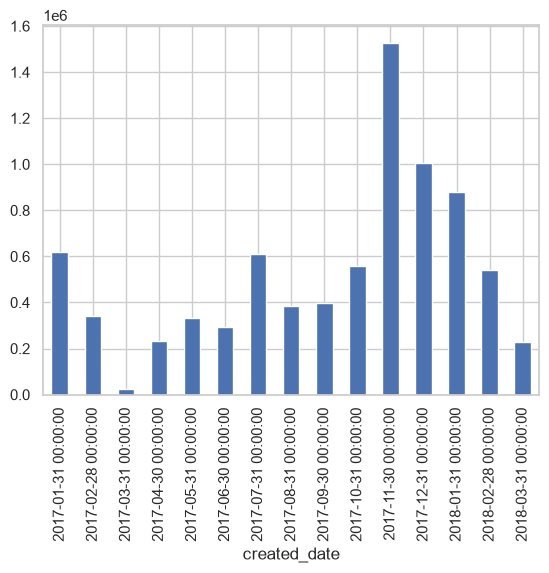

In [76]:
merge_df["created_date"] = pd.to_datetime(merge_df["created_date"])
orders_unique = merge_df.drop_duplicates(subset="order_id")
orders_unique.resample("ME", on="created_date")["total_paid"].sum().plot(kind="bar")

Ok below is the discount in percentage, because I like it that way, and it feels more significant in general for grouping later.

In [77]:
merge_df["discount_percentage"] = ((merge_df["discount"] / merge_df["price"]) * 100).round(2)

Below a similar graph to the one above, but this one tracks average discounts over the entire stock. Again you can play with resolution, changing to day makes it ugly, but telling.

<Axes: xlabel='created_date'>

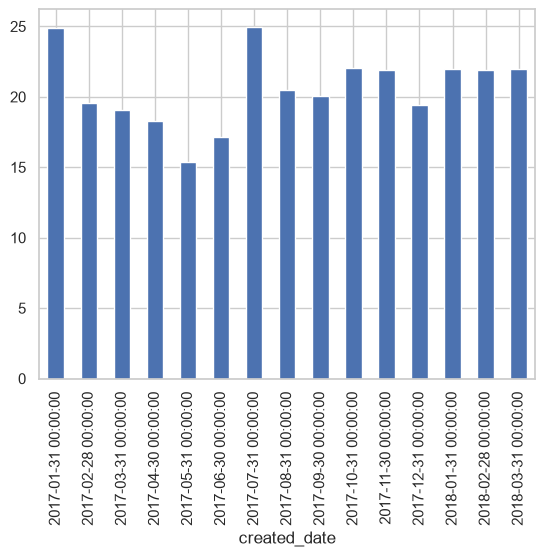

In [78]:
merge_df.resample("ME", on="created_date")["discount_percentage"].mean().plot(kind="bar")

Ok, so lets figure out which products are our bestsellers - first in terms of pure numbers. Below one version for orderlines, and one for our merged file. They are equivalent.

<Axes: ylabel='sku'>

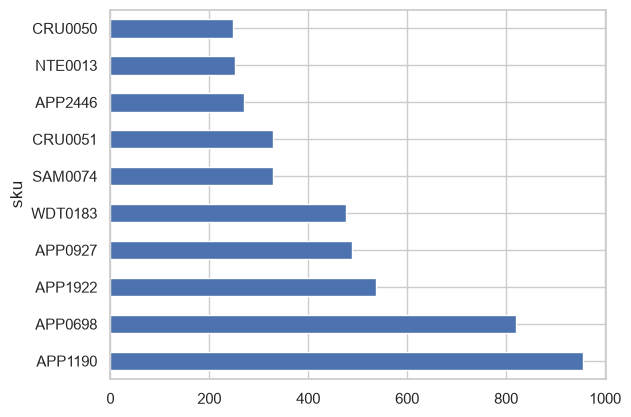

In [79]:
orderlines_qu.groupby("sku")["product_quantity"].sum().sort_values(ascending=False).head(10).plot(kind="barh")

<Axes: ylabel='sku'>

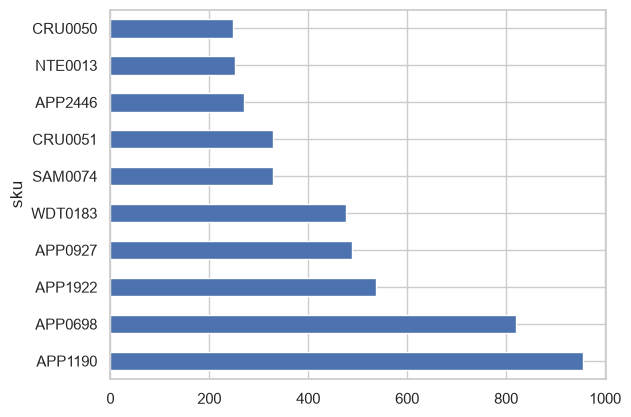

In [80]:
merge_df.groupby("sku")["product_quantity"].sum().sort_values(ascending=False).head(10).plot(kind="barh")

Ok cool, but if you look those SKUs up, they'll be like cheap USB cables or some such. Exercise - also pull in the product names. Wait, lets try that here below:

<Axes: ylabel='sku,name'>

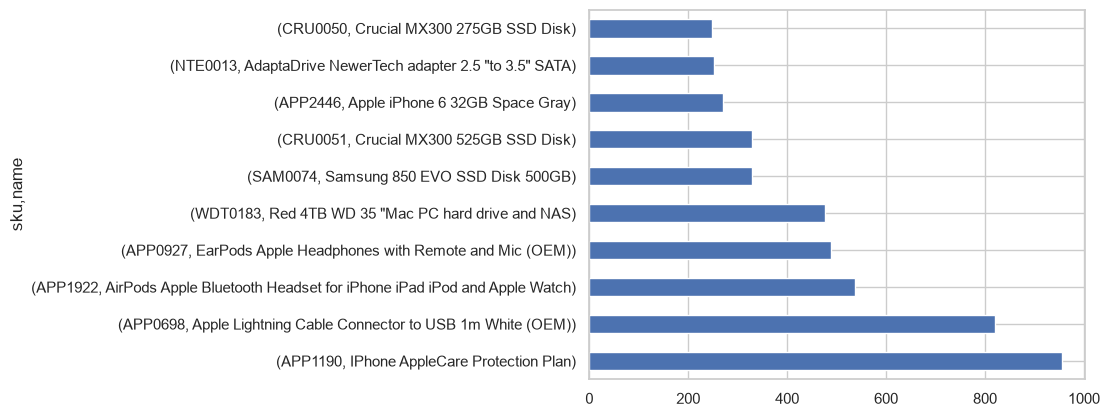

In [81]:
merge_df.groupby(["sku", "name"])["product_quantity"].agg("sum").sort_values(ascending=False).head(10).plot(kind="barh")

Ok, so have a quick think why grouping for both works so nicely (generally it wouldn't). Solution: SKU and name are in a 1-1 correspondance.

Ok, now lets check which products drive revenue instead. Here we'll work with prices, so lets first account for sales in multiples, and then do the same kind of chart as above.

In [82]:
merge_df["total_sale_price"] = merge_df["unit_price"] * merge_df["product_quantity"]

<Axes: ylabel='sku,name'>

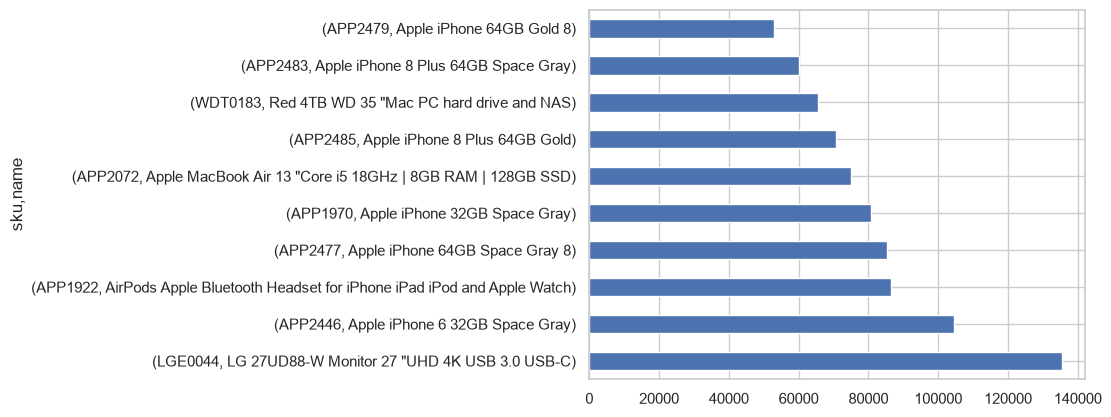

In [83]:
merge_df.groupby(["sku", "name"])["total_sale_price"].sum().sort_values(ascending=False).head(10).plot(kind="barh")

Cool, those would be our revenue drivers. If you kill the .plot, and change the argument in .head, you can easily pull a larger range of high earners for further analysis. THing to try: Do this with like the upper quartile (quartiles are built in!) or like with the upper 20% to check the pareto principle.

Things to try: Maybe look at individual items, when are they sold? Like when they selling? What proportions of sales are with discounts? Maybe with examples of high and low earners, high and low cost items etc. First lets redo the table above with more data, and name them in case I want to reuse them later.

In [84]:
top10 = merge_df.groupby(["sku", "name"]).agg({"total_sale_price": "sum", "price": "first", "product_quantity": "sum"}).sort_values("total_sale_price", ascending=False).head(10)

In [85]:
top10

,,total_sale_price,price,product_quantity
sku,name,,,
LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",135375.83,599.00,239
APP2446,Apple iPhone 6 32GB Space Gray,104560.64,449.33,270
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,86473.26,179.00,537
APP2477,Apple iPhone 64GB Space Gray 8,85301.93,809.00,108
APP1970,Apple iPhone 32GB Space Gray,80715.76,419.00,223
APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",74964.06,1105.59,77
APP2485,Apple iPhone 8 Plus 64GB Gold,70721.79,919.00,79
WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",65589.96,169.00,476
APP2483,Apple iPhone 8 Plus 64GB Space Gray,60090.08,919.00,67


We can do an individual analysis. Like that that monitor that is our best earner, LGE044. When does it sell? Which discounts drive sales, if any?

In [86]:
merge_df.loc[merge_df["sku"]=="LGE0044", ["name", "total_sale_price", "product_quantity", "discount_percentage"]].groupby("discount_percentage").agg({"total_sale_price": "sum", "product_quantity": "sum"}).sort_values("discount_percentage", ascending=False)

,total_sale_price,product_quantity
discount_percentage,,
11.07,532.67,1
10.96,3200.22,6
8.35,25254.00,46
7.21,555.83,1
6.51,25759.54,46
6.24,1123.24,2
6.18,5619.90,10
5.79,1128.58,2
5.27,2837.05,5


Ok, that code might take some parsing, but it is not difficult - I simply group all the sales of it along the different prices it got sold at, but describe them in percentages against the catalog price. Why no 0.0 appears I have no idea - perhaps it is always discounted to some extent (check!) or perhaps the price recently got raised so that the lower discounts here represents older price points. Anyway, lets graph this:

<Axes: xlabel='discount_percentage'>

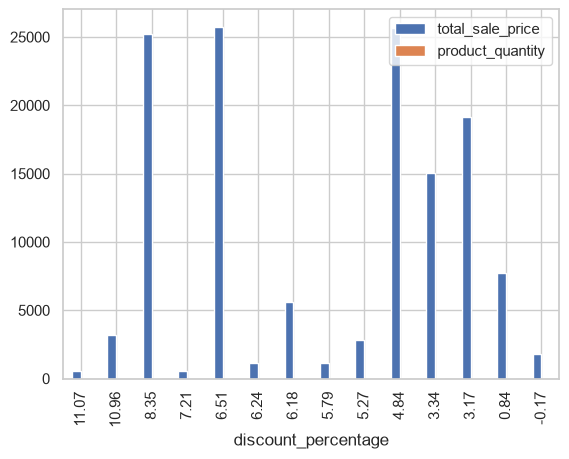

In [87]:
merge_df.loc[merge_df["sku"]=="LGE0044", ["name", "total_sale_price", "product_quantity", "discount_percentage"]].groupby("discount_percentage").agg({"total_sale_price": "sum", "product_quantity": "sum"}).sort_values("discount_percentage", ascending=False).plot(kind="bar")

Ok, so it looks kinda like some discount helps? Maybe? Things to think about for further analysis: How long were the windows of higher discount, does the frequency of sales rise? (THAT SOUDNS LIKE AN IMPORTANT THING TO TRY BUT DIFFICULT). How do the other top earners look? Try individually and with the Top10 (.isin would help here), and maybe with upper quartile.

As a first step, and last analysis for the day, here is a fun one for the entire sortiment. We can bin discounts into ranges of 10, see the first code line below (note: you could also start at like -10 or -20 or so, an oddly large amount of sales have a negative discount. I assume they correspond to older, permanently higher price points).

The second line is just a nice groupby on these bins, and we look at total sales in euros and units. This is for the everything at once, but should be repeated with different segments (in terms of earnings and sales, think quartiles or such).

In [88]:
merge_df["discount_bin"] = pd.cut(merge_df["discount_percentage"], bins=range(0, 101, 10))

merge_df.groupby("discount_bin", observed=True).agg(total_sale_price=("total_sale_price", "sum"), product_quantity=("product_quantity", "sum"))


,total_sale_price,product_quantity
discount_bin,,
"(0, 10]",2681656.53,12254
"(10, 20]",2569012.88,17208
"(20, 30]",1386790.69,12379
"(30, 40]",339697.43,5034
"(40, 50]",114120.63,3017
"(50, 60]",73018.05,2239
"(60, 70]",43060.82,2097
"(70, 80]",29836.54,1053
"(80, 90]",2408.50,352


A quick look tellls us that the vast majority of our sales occur at no, or a smaller < 30% discount... that might not be that telling though, compare and contrast with the spread of discounts over time as a share...

Ok, there you have a few ideas for further analysis, and some examples of code (probably clunky, but eh).

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Ok, lets do a boolean column for if a product is discounted at all. I'll set the limit at 5% to reduce noice in pricing. We add it as a separate column.

In [90]:
merge_df["is_discounted"] = merge_df["discount_percentage"] > 5
#merge_df["is_discounted"].value_counts()
merge_df.groupby("sku").agg(all_discounted=("is_discounted", "all")).value_counts()

all_discounted
True              3865
False             1233
Name: count, dtype: int64

In [91]:
top10

,,total_sale_price,price,product_quantity
sku,name,,,
LGE0044,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",135375.83,599.00,239
APP2446,Apple iPhone 6 32GB Space Gray,104560.64,449.33,270
APP1922,AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,86473.26,179.00,537
APP2477,Apple iPhone 64GB Space Gray 8,85301.93,809.00,108
APP1970,Apple iPhone 32GB Space Gray,80715.76,419.00,223
APP2072,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",74964.06,1105.59,77
APP2485,Apple iPhone 8 Plus 64GB Gold,70721.79,919.00,79
WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",65589.96,169.00,476
APP2483,Apple iPhone 8 Plus 64GB Space Gray,60090.08,919.00,67


Ok below is some black magic - i will not be using that again, but it'S nice to have seen once. So suppose I want to get the merge_df entries with the sku's from top10. The thing is that from the groupby on two values, we now have a multiindex. You can pull the, out with .index.get_level_values("subindexname"). Zip pairs them up again, and dict makes it into a dictionary, which is cool but not really necessary.

The meatier part is the first line where we pull the skus, and then we create a top10_df which is basucally just the merge_df filtered by skus in the top 10 with a isin.

In [92]:
top10_skus = top10.index.get_level_values("sku").tolist()
sku_to_name = dict(zip(top10.index.get_level_values("sku"), top10.index.get_level_values("name")))

top10_df = merge_df[merge_df["sku"].isin(top10_skus)].sort_values(["sku", "created_date"]).copy()
top10_df["is_discounted"] = top10_df["discount_percentage"] > 1
top10_df.head()

,order_id,created_date,total_paid,state,id,id_order,product_id,product_quantity,sku,unit_price,...,name,desc,price,in_stock,type,discount,discount_percentage,total_sale_price,discount_bin,is_discounted
11546,354141,2017-05-10 12:10:57,179.00,Completed,1244403,354141,0,1,APP1922,179.0,...,AirPods Apple Bluetooth Headset for iPhone iPa...,Apple AirPods wireless headsets and cargo tran...,179.0,1,5384,0.0,0.0,179.0,NaN,False
11547,354142,2017-05-12 12:06:42,179.00,Completed,1244404,354142,0,1,APP1922,179.0,...,AirPods Apple Bluetooth Headset for iPhone iPa...,Apple AirPods wireless headsets and cargo tran...,179.0,1,5384,0.0,0.0,179.0,NaN,False
11545,354140,2017-05-22 13:58:56,185.99,Completed,1252288,354140,0,1,APP1922,179.0,...,AirPods Apple Bluetooth Headset for iPhone iPa...,Apple AirPods wireless headsets and cargo tran...,179.0,1,5384,0.0,0.0,179.0,NaN,False
12051,356226,2017-05-22 15:37:49,179.00,Completed,1248702,356226,0,1,APP1922,179.0,...,AirPods Apple Bluetooth Headset for iPhone iPa...,Apple AirPods wireless headsets and cargo tran...,179.0,1,5384,0.0,0.0,179.0,NaN,False
11880,355464,2017-06-14 12:24:13,185.99,Completed,1247116,355464,0,1,APP1922,179.0,...,AirPods Apple Bluetooth Headset for iPhone iPa...,Apple AirPods wireless headsets and cargo tran...,179.0,1,5384,0.0,0.0,179.0,NaN,False


Lets take a look at discounts over time, and how big a share of sales over time were discounted. I'll do this in one figure with two plots, hence we use fig as a wrapper and use subplots. Since they both are over the same time series, we can do sharex=True to force alignment. Instead of resample, we can kind of pre-binwith dt.to_period here.

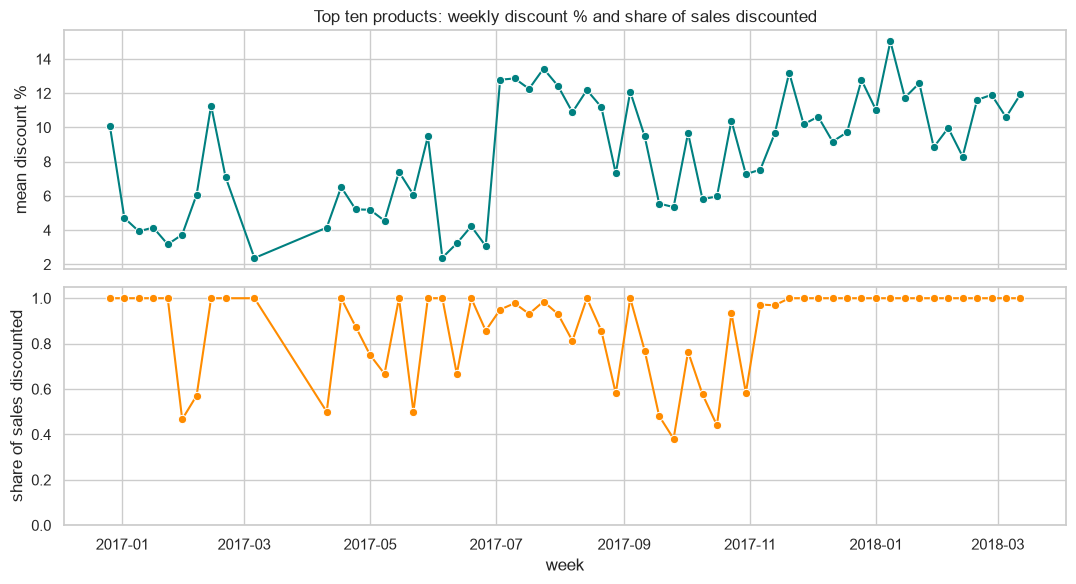

In [93]:
top10_df["week"] = top10_df["created_date"].dt.to_period("W").dt.start_time
weekly_top10 = top10_df.groupby("week").agg(
    mean_discount_pct=("discount_percentage", "mean"),
    share_discounted=("is_discounted", "mean"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
sns.lineplot(data=weekly_top10, x="week", y="mean_discount_pct", marker="o", ax=axes[0], color="teal")
axes[0].set_title("Top ten products: weekly discount % and share of sales discounted")
axes[0].set_ylabel("mean discount %")
sns.lineplot(data=weekly_top10, x="week", y="share_discounted", marker="o", ax=axes[1], color="darkorange")
axes[1].set_ylabel("share of sales discounted")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()

Heyyy, lets redo this with more products. Hey the pareto principle seems to hold up, 20% of the inventory accounts for 80% of sales - thats always a nice heuristic to use to reduce noise.

In [94]:
selling_df = merge_df.groupby(["sku", "name"]).agg({"total_sale_price": "sum", "price": "first", "product_quantity": "sum"})
threshold = selling_df["total_sale_price"].quantile(0.8)
top20_df = selling_df[selling_df["total_sale_price"] >= threshold].sort_values("total_sale_price", ascending=False).reset_index()

paretocheck= top20_df["total_sale_price"].sum() / merge_df["total_sale_price"].sum()
paretocheck

np.float64(0.8468365238089464)

lets pull the transactions concerning those into a separate data frame:

In [95]:
merge_20_df = merge_df[merge_df["sku"].isin(top20_df["sku"])].sort_values(["sku", "created_date"]).copy()

In [96]:
merge_20_df

,order_id,created_date,total_paid,state,id,id_order,product_id,product_quantity,sku,unit_price,...,name,desc,price,in_stock,type,discount,discount_percentage,total_sale_price,discount_bin,is_discounted
225,299945,2017-01-01 21:19:31,147.47,Completed,1119924,299945,0,2,ADN0042,71.24,...,Adonith Pixel Pointer Black,Bluetooth digital pen tip 19mm for iPhone and ...,74.99,1,1229,3.75,5.00,142.48,"(0.0, 10.0]",False
7012,321388,2017-02-08 16:17:10,78.98,Completed,1174446,321388,0,1,ADN0042,74.99,...,Adonith Pixel Pointer Black,Bluetooth digital pen tip 19mm for iPhone and ...,74.99,1,1229,0.00,0.00,74.99,NaN,False
8175,325656,2017-02-17 13:43:08,74.99,Completed,1184102,325656,0,1,ADN0042,74.99,...,Adonith Pixel Pointer Black,Bluetooth digital pen tip 19mm for iPhone and ...,74.99,1,1229,0.00,0.00,74.99,NaN,False
11338,353272,2017-05-06 17:24:47,134.97,Completed,1242729,353272,0,1,ADN0042,74.99,...,Adonith Pixel Pointer Black,Bluetooth digital pen tip 19mm for iPhone and ...,74.99,1,1229,0.00,0.00,74.99,NaN,False
11572,354221,2017-05-09 15:40:45,74.99,Completed,1244573,354221,0,1,ADN0042,74.99,...,Adonith Pixel Pointer Black,Bluetooth digital pen tip 19mm for iPhone and ...,74.99,1,1229,0.00,0.00,74.99,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52935,525588,2018-03-11 20:51:45,44.98,Completed,1646412,525588,0,1,ZAG0032,39.99,...,Rugged Messenger Zagg iPad Keyboard Folio (201...,Keyboard folio and adjustable position for 97-...,99.99,1,12575403,60.00,60.01,39.99,"(60.0, 70.0]",True
52945,525638,2018-03-11 22:25:47,86.97,Completed,1646513,525638,0,1,ZAG0032,39.99,...,Rugged Messenger Zagg iPad Keyboard Folio (201...,Keyboard folio and adjustable position for 97-...,99.99,1,12575403,60.00,60.01,39.99,"(60.0, 70.0]",True
53015,525908,2018-03-12 13:43:03,44.98,Completed,1647083,525908,0,1,ZAG0032,39.99,...,Rugged Messenger Zagg iPad Keyboard Folio (201...,Keyboard folio and adjustable position for 97-...,99.99,1,12575403,60.00,60.01,39.99,"(60.0, 70.0]",True
53049,526052,2018-03-12 18:00:08,44.98,Completed,1647398,526052,0,1,ZAG0032,39.99,...,Rugged Messenger Zagg iPad Keyboard Folio (201...,Keyboard folio and adjustable position for 97-...,99.99,1,12575403,60.00,60.01,39.99,"(60.0, 70.0]",True


I'll repeat the figure above but with this new set - and im more interested in share of revenue than share of items moved:

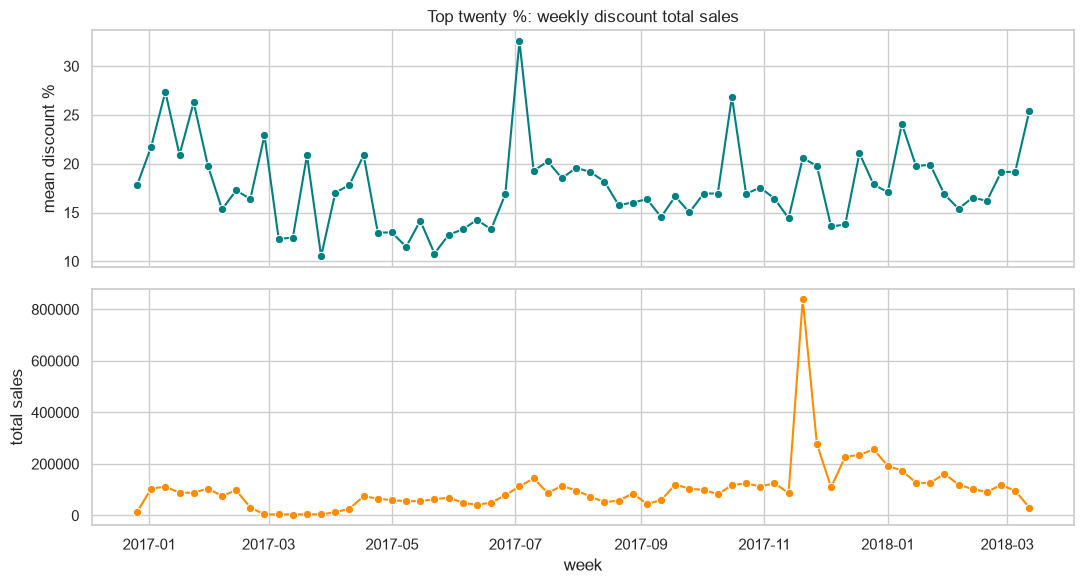

In [97]:
merge_20_df["week"] = merge_20_df["created_date"].dt.to_period("W").dt.start_time
weekly_top20 = merge_20_df.groupby("week").agg(
    mean_discount_pct=("discount_percentage", "mean"),
    total_sales=("total_sale_price", "sum"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
sns.lineplot(data=weekly_top20, x="week", y="mean_discount_pct", marker="o", ax=axes[0], color="teal")
axes[0].set_title("Top twenty %: weekly discount total sales")
axes[0].set_ylabel("mean discount %")
sns.lineplot(data=weekly_top20, x="week", y="total_sales", marker="o", ax=axes[1], color="darkorange")
axes[1].set_ylabel("total sales")
plt.tight_layout()

Ok, for comparison it IS possible to pull them both onto the same chart. You do this by defining two axes, and setting the second one to be equal to the first with .twin().

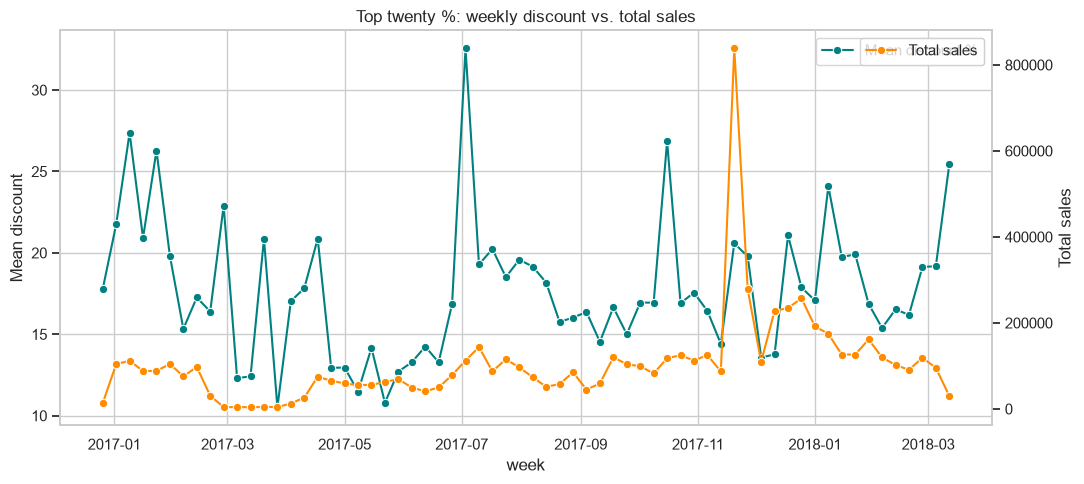

In [100]:
fig, ax1 = plt.subplots(figsize=(11, 5))

sns.lineplot(data=weekly_top20, x="week", y="mean_discount_pct", marker="o", ax=ax1, color="teal", label="Mean discount %")
ax1.set_ylabel("Mean discount")

ax2 = ax1.twinx() #here's where the magic happens, you can have two y-axes on the same plot
sns.lineplot(data=weekly_top20, x="week", y="total_sales", marker="o", ax=ax2, color="darkorange", label="Total sales")
ax2.set_ylabel("Total sales")
ax2.grid(False)  # YOu totally want this to remve gridline messes, the different scales of the y-axes otherwise mess things up
ax1.set_title("Top twenty %: weekly discount vs. total sales")

plt.tight_layout() #this is just a prettyfing thing, it makes sure the labels and titles don't overlap with the plot area

And last and least, I used an LLM to help me create a grid plot for the top selling items- You still use a fig wrapper and subplots, but you seem to have to adjust EACH plot, whence we instead run a loop over them adjusting everything. NOt THAT technical, apart from some nice layouting lines you can crib. If you understand the figure above, you'll understand what hapens in this one below with enough staring at the code.

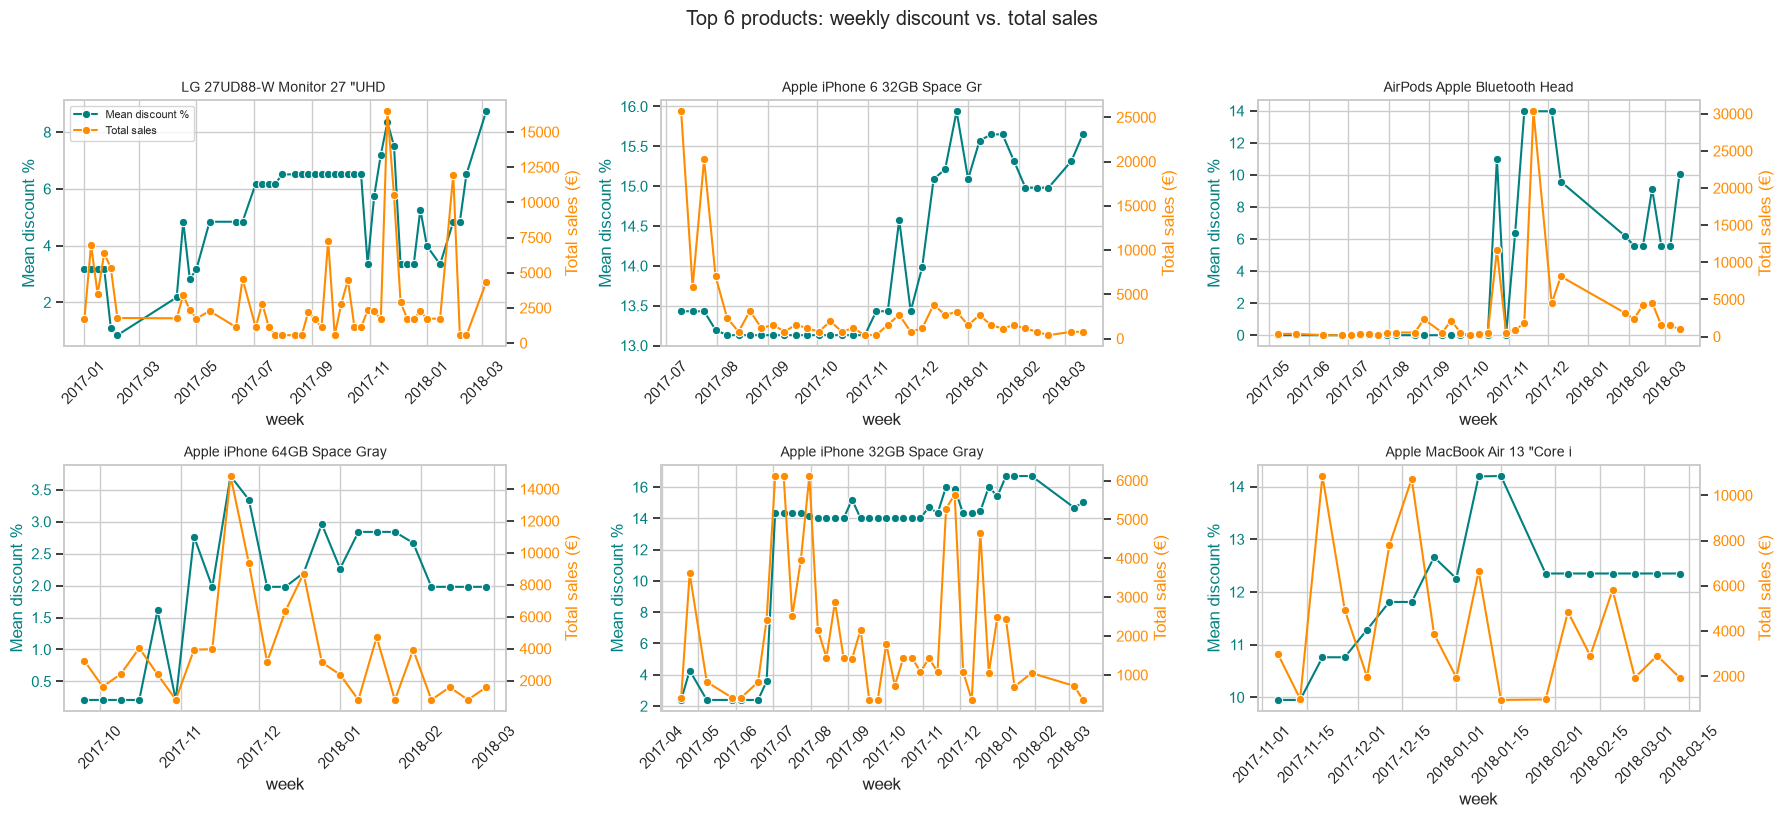

In [102]:
top6_skus = top10_skus[:6]  # from your earlier top10 groupby, sliced to 6

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, sku in enumerate(top6_skus):
    ax1 = axes[i]

    sub = merge_df.loc[merge_df["sku"] == sku].copy()
    sub["week"] = sub["created_date"].dt.to_period("W").dt.start_time
    weekly = sub.groupby("week").agg(
        mean_discount_pct=("discount_percentage", "mean"),
        total_sales=("total_sale_price", "sum"),
    ).reset_index()

    sns.lineplot(data=weekly, x="week", y="mean_discount_pct", marker="o", ax=ax1, color="teal", label="Mean discount %")
    ax1.set_ylabel("Mean discount %", color="teal")
    ax1.tick_params(axis="y", labelcolor="teal")

    ax2 = ax1.twinx()
    sns.lineplot(data=weekly, x="week", y="total_sales", marker="o", ax=ax2, color="darkorange", label="Total sales")
    ax2.set_ylabel("Total sales (€)", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax2.grid(False)

    ax1.set_title(sku_to_name[sku][:28], fontsize=10)
    ax1.tick_params(axis="x", rotation=45)

    # merge the two per-axes legends into one, then only keep it on the first subplot
    ax1.legend_.remove()
    ax2.legend_.remove()
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

fig.suptitle("Top 6 products: weekly discount vs. total sales", y=1.02)
plt.tight_layout()